# MIT-BIH Arrhythmia ECG Processing with NeuroKit2

This notebook shows an end-to-end, reproducible workflow for loading an original MIT-BIH Arrhythmia Database record, cleaning the ECG signal, detecting and delineating cardiac waves, extracting HRV features, and visualizing model outputs against expert annotations.

The example uses **record `100`** from the MIT-BIH Arrhythmia Database and prefers the **MLII** lead, which is commonly used for arrhythmia analysis in this dataset.

Official references used for this workflow:

- NeuroKit2 ECG API: https://neuropsychology.github.io/NeuroKit/functions/ecg.html
- WFDB Python docs: https://wfdb.readthedocs.io/en/latest/wfdb.html
- WFDB basic MIT-BIH example: https://wfdb.io/software/python.html
- PhysioNet MIT-BIH files: https://physionet.org/content/mitdb/

## 1. Environment Setup

Install the required packages once in your notebook environment if they are not already available.

> Tip: run package installation in a separate cell, then restart the Jupyter kernel before executing the analysis cells.

In [1]:
# Optional: uncomment this cell if the packages are not installed in your environment.
# %pip install neurokit2 wfdb matplotlib seaborn pandas numpy scipy

In [2]:
from pathlib import Path
import warnings

import neurokit2 as nk
import wfdb
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

warnings.filterwarnings("ignore", category=RuntimeWarning)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print("NeuroKit2:", nk.__version__)
print("WFDB:", wfdb.__version__)

NeuroKit2: 0.2.13
WFDB: 4.3.1


## 2. Load an Original MIT-BIH Record and Expert Annotations

`wfdb.rdrecord()` loads the ECG waveform and metadata. `wfdb.rdann()` loads the expert beat annotations from the `.atr` annotation file.

This cell supports two modes:

1. **Local dataset mode**: if you already downloaded files such as `100.hea`, `100.dat`, and `100.atr`, set `MITBIH_LOCAL_DIR` to that folder.
2. **PhysioNet streaming mode**: if local files are absent, WFDB streams record `100` from the public `mitdb` PhysioNet directory.

For faster experimentation, the notebook reads the first `10` minutes by default. Increase `DURATION_SECONDS` or set it to `None` for the full record.

In [3]:
# -----------------------------
# User-adjustable configuration
# -----------------------------
RECORD_NAME = "100"
PN_DIR = "mitdb"  # PhysioNet short name for the MIT-BIH Arrhythmia Database
DURATION_SECONDS = 10 * 60  # use None to load the complete record

# Change this if your original MIT-BIH files are stored somewhere else.
# Expected local files for record 100: 100.hea, 100.dat, 100.atr
MITBIH_LOCAL_DIR = Path("data/mitdb")


def load_mitbih_record(record_name: str, local_dir: Path | None = None, duration_seconds: int | None = None):
    """Load a MIT-BIH WFDB record and its expert annotations.

    The function first tries local WFDB files. If they are not present, it streams
    directly from PhysioNet using pn_dir='mitdb'.
    """
    local_dir = Path(local_dir) if local_dir is not None else None

    # Load the header first when possible, so we know the sampling frequency before sampto.
    if local_dir and (local_dir / f"{record_name}.hea").exists():
        record_base = str(local_dir / record_name)
        header = wfdb.rdheader(record_base)
        source_description = f"local files: {local_dir.resolve()}"
        pn_dir = None
    else:
        record_base = record_name
        header = wfdb.rdheader(record_base, pn_dir=PN_DIR)
        source_description = f"PhysioNet pn_dir='{PN_DIR}'"
        pn_dir = PN_DIR

    sampling_rate = int(header.fs)
    sampto = None if duration_seconds is None else int(duration_seconds * sampling_rate)

    if pn_dir is None:
        record = wfdb.rdrecord(record_base, sampto=sampto)
        annotation = wfdb.rdann(record_base, "atr", sampto=sampto)
    else:
        record = wfdb.rdrecord(record_base, pn_dir=pn_dir, sampto=sampto)
        annotation = wfdb.rdann(record_base, "atr", pn_dir=pn_dir, sampto=sampto)

    return record, annotation, source_description


record, annotation, source_description = load_mitbih_record(
    RECORD_NAME,
    local_dir=MITBIH_LOCAL_DIR,
    duration_seconds=DURATION_SECONDS,
)

sampling_rate = int(record.fs)
signal_names = list(record.sig_name)

print(f"Loaded MIT-BIH record {RECORD_NAME} from {source_description}")
print(f"Sampling rate: {sampling_rate} Hz")
print(f"Available leads: {signal_names}")
print(f"Signal shape: {record.p_signal.shape}")
print(f"Expert annotations loaded: {len(annotation.sample)}")

Loaded MIT-BIH record 100 from PhysioNet pn_dir='mitdb'
Sampling rate: 360 Hz
Available leads: ['MLII', 'V5']
Signal shape: (216000, 2)
Expert annotations loaded: 761


In [4]:
# Prefer the MLII lead when it exists. Otherwise, fall back to the first channel.
if "MLII" in signal_names:
    lead_index = signal_names.index("MLII")
else:
    lead_index = 0

lead_name = signal_names[lead_index]
raw_ecg = pd.Series(record.p_signal[:, lead_index], name=f"ECG_Raw_{lead_name}")
time = np.arange(len(raw_ecg)) / sampling_rate

# Store expert annotations in a compact DataFrame for later visualization/evaluation.
expert_annotations = pd.DataFrame({
    "sample": annotation.sample,
    "time_sec": annotation.sample / sampling_rate,
    "symbol": annotation.symbol,
    "aux_note": annotation.aux_note,
})

print(f"Using lead: {lead_name}")
display(expert_annotations.head(10))

Using lead: MLII


,sample,time_sec,symbol,aux_note
0,18,0.050000,+,(N 
1,77,0.213889,N,
2,370,1.027778,N,
3,662,1.838889,N,
4,946,2.627778,N,
5,1231,3.419444,N,
6,1515,4.208333,N,
7,1809,5.025000,N,
8,2044,5.677778,A,
9,2402,6.672222,N,


## 3. Signal Preprocessing and Cleaning

`nk.ecg_clean()` filters the raw ECG channel. The `method='neurokit'` pipeline is a robust default for general ECG preprocessing. It reduces baseline wander and high-frequency noise while preserving QRS morphology for downstream peak detection.

You can switch to `method='pantompkins1985'` if you want a Pan-Tompkins-style preprocessing path, but `method='neurokit'` is usually a good production default for NeuroKit2 workflows.

In [5]:
cleaned_ecg = nk.ecg_clean(
    raw_ecg,
    sampling_rate=sampling_rate,
    method="neurokit",  # alternative: "pantompkins1985"
)

cleaned_ecg = pd.Series(cleaned_ecg, name=f"ECG_Clean_{lead_name}")

cleaning_summary = pd.DataFrame({
    "raw_mean": [raw_ecg.mean()],
    "raw_std": [raw_ecg.std()],
    "clean_mean": [cleaned_ecg.mean()],
    "clean_std": [cleaned_ecg.std()],
})

display(cleaning_summary)

,raw_mean,raw_std,clean_mean,clean_std
0,-0.316429,0.179037,-0.000017,0.135196


## 4. R-Peak Detection and ECG Wave Delineation

`nk.ecg_peaks()` identifies R-peaks and returns:

- `signals`: a sample-by-sample DataFrame containing binary peak indicator columns.
- `info`: a dictionary containing exact R-peak sample indices under `ECG_R_Peaks`.

`nk.ecg_delineate()` uses the cleaned ECG and detected R-peaks to locate P, Q, R, S, and T waveform landmarks. The `method='dwt'` option uses Discrete Wavelet Transform delineation, which is well suited for precise ECG fiducial point detection.

In [6]:
# Detect R-peaks on the cleaned ECG signal.
peak_signals, peak_info = nk.ecg_peaks(
    cleaned_ecg,
    sampling_rate=sampling_rate,
    method="neurokit",
)

rpeaks = np.asarray(peak_info["ECG_R_Peaks"], dtype=int)
print(f"Detected R-peaks: {len(rpeaks)}")
print("First 10 R-peak sample locations:", rpeaks[:10])

# Delineate P/Q/S/T peaks plus wave onsets and offsets using DWT.
delineate_signals, delineate_info = nk.ecg_delineate(
    cleaned_ecg,
    rpeaks=rpeaks,
    sampling_rate=sampling_rate,
    method="dwt",
)

print("Delineation keys:")
print(sorted(delineate_info.keys()))

Detected R-peaks: 759
First 10 R-peak sample locations: [ 370  662  946 1231 1515 1809 2044 2402 2706 2997]
Delineation keys:
['ECG_P_Offsets', 'ECG_P_Onsets', 'ECG_P_Peaks', 'ECG_Q_Peaks', 'ECG_R_Offsets', 'ECG_R_Onsets', 'ECG_S_Peaks', 'ECG_T_Offsets', 'ECG_T_Onsets', 'ECG_T_Peaks']


## 5. Feature Extraction: HRV and Full ECG Processing Summary

`nk.hrv()` computes a broad HRV feature table from R-peak locations, including:

- **Time-domain** features such as mean NN interval, SDNN, RMSSD, pNN50.
- **Frequency-domain** features such as LF, HF, LF/HF when the segment is long enough for spectral estimation.
- **Nonlinear** features such as Poincaré SD1/SD2 and entropy/fractal metrics where applicable.

`nk.ecg_process()` is NeuroKit2's high-level ECG pipeline. It combines cleaning, R-peak detection, heart-rate estimation, signal quality, QRS delineation, and phase estimation into one processed signal DataFrame and an info dictionary.

In [7]:
# Comprehensive HRV metrics. For publication-quality frequency-domain HRV,
# prefer several minutes of clean, stable ECG.
hrv_features = nk.hrv(
    peaks=rpeaks,
    sampling_rate=sampling_rate,
    show=False,
)

# Full NeuroKit ECG processing pipeline. This gives a single aligned DataFrame
# containing cleaned ECG, R-peaks, rate, quality, delineation signals, and phases.
ecg_summary, ecg_info = nk.ecg_process(
    raw_ecg,
    sampling_rate=sampling_rate,
    method="neurokit",
)

print("ECG summary DataFrame shape:", ecg_summary.shape)
print("ECG summary columns:")
print(ecg_summary.columns.tolist())

display(hrv_features.T.rename(columns={0: "value"}).head(40))
display(ecg_summary.head())

ECG summary DataFrame shape: (216000, 19)
ECG summary columns:
['ECG_Raw', 'ECG_Clean', 'ECG_Rate', 'ECG_Quality', 'ECG_R_Peaks', 'ECG_P_Peaks', 'ECG_P_Onsets', 'ECG_P_Offsets', 'ECG_Q_Peaks', 'ECG_R_Onsets', 'ECG_R_Offsets', 'ECG_S_Peaks', 'ECG_T_Peaks', 'ECG_T_Onsets', 'ECG_T_Offsets', 'ECG_Phase_Atrial', 'ECG_Phase_Completion_Atrial', 'ECG_Phase_Ventricular', 'ECG_Phase_Completion_Ventricular']


,value
HRV_MeanNN,789.651129
HRV_SDNN,44.888174
HRV_SDANN1,23.683303
HRV_SDNNI1,37.617659
HRV_SDANN2,24.529289
HRV_SDNNI2,38.651333
HRV_SDANN5,NaN
HRV_SDNNI5,NaN
HRV_RMSSD,49.437550
HRV_SDSD,49.470233


,ECG_Raw,ECG_Clean,ECG_Rate,ECG_Quality,ECG_R_Peaks,ECG_P_Peaks,ECG_P_Onsets,ECG_P_Offsets,ECG_Q_Peaks,ECG_R_Onsets,ECG_R_Offsets,ECG_S_Peaks,ECG_T_Peaks,ECG_T_Onsets,ECG_T_Offsets,ECG_Phase_Atrial,ECG_Phase_Completion_Atrial,ECG_Phase_Ventricular,ECG_Phase_Completion_Ventricular
0,-0.145,0.041642,75.982922,0.96876,0,0,0,0,0,0,0,0,0,0,0,NaN,0.0,NaN,0.0
1,-0.145,0.042106,75.982922,0.96876,0,0,0,0,0,0,0,0,0,0,0,NaN,0.0,NaN,0.0
2,-0.145,0.043079,75.982922,0.96876,0,0,0,0,0,0,0,0,0,0,0,NaN,0.0,NaN,0.0
3,-0.145,0.044257,75.982922,0.96876,0,0,0,0,0,0,0,0,0,0,0,NaN,0.0,NaN,0.0
4,-0.145,0.045435,75.982922,0.96876,0,0,0,0,0,0,0,0,0,0,0,NaN,0.0,NaN,0.0


## 6. Visualization: Raw vs. Cleaned ECG Signal

A short raw-vs-clean comparison is the fastest way to sanity-check filtering. The cleaned signal should preserve the QRS complexes while reducing slow baseline drift and high-frequency noise.

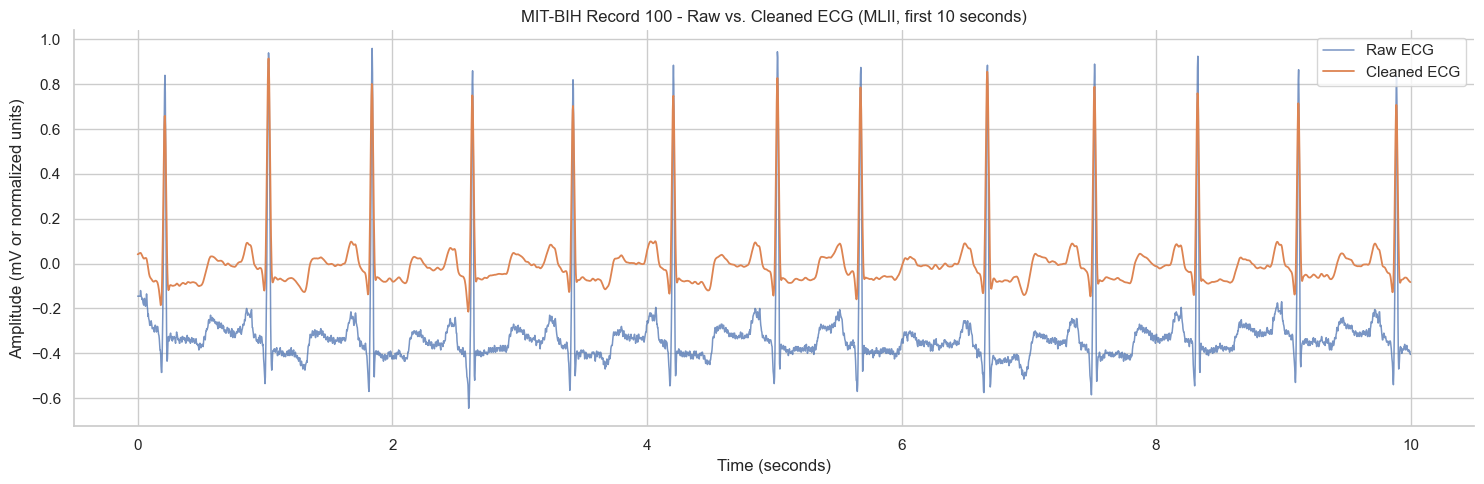

In [8]:
def window_slice(start_seconds: float, duration_seconds: float, fs: int, n_samples: int) -> slice:
    """Return a safe sample slice for a time window."""
    start = max(0, int(start_seconds * fs))
    stop = min(n_samples, start + int(duration_seconds * fs))
    return slice(start, stop)

raw_clean_window = window_slice(start_seconds=0, duration_seconds=10, fs=sampling_rate, n_samples=len(raw_ecg))
window_time = time[raw_clean_window]

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(window_time, raw_ecg.iloc[raw_clean_window], label="Raw ECG", linewidth=1.1, alpha=0.75)
ax.plot(window_time, cleaned_ecg.iloc[raw_clean_window], label="Cleaned ECG", linewidth=1.3)
ax.set_title(f"MIT-BIH Record {RECORD_NAME} - Raw vs. Cleaned ECG ({lead_name}, first 10 seconds)")
ax.set_xlabel("Time (seconds)")
ax.set_ylabel("Amplitude (mV or normalized units)")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## 7. Visualization: P, Q, R, S, and T Peak Markers

This 5-second plot overlays ECG wave landmarks from DWT delineation:

- **P peaks**: atrial depolarization.
- **Q, R, S peaks**: QRS complex / ventricular depolarization.
- **T peaks**: ventricular repolarization.

The helper below safely handles missing or `NaN` delineation points, which are normal near window edges or noisy beats.

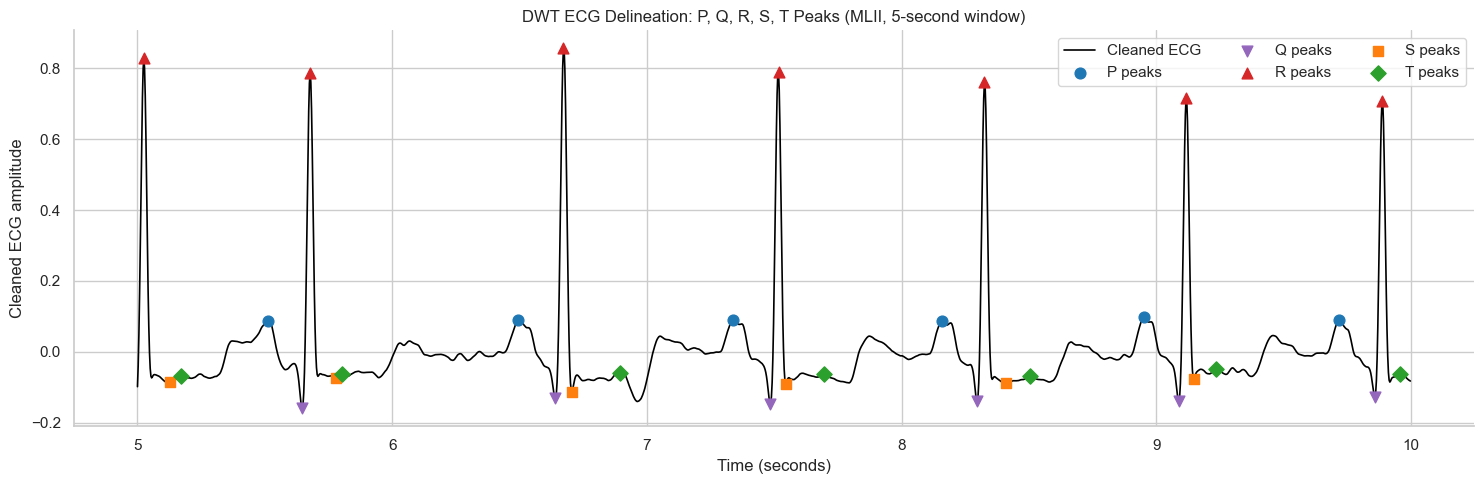

In [9]:
def valid_indices(indices, start: int, stop: int) -> np.ndarray:
    """Convert NeuroKit index lists to valid integer sample positions inside a window."""
    if indices is None:
        return np.array([], dtype=int)

    values = pd.Series(indices).dropna().astype(int).to_numpy()
    values = values[(values >= start) & (values < stop)]
    values = values[(values >= 0) & (values < len(cleaned_ecg))]
    return values

wave_window = window_slice(start_seconds=5, duration_seconds=5, fs=sampling_rate, n_samples=len(cleaned_ecg))
start_sample, stop_sample = wave_window.start, wave_window.stop

wave_markers = {
    "P": {"samples": delineate_info.get("ECG_P_Peaks"), "color": "tab:blue", "marker": "o"},
    "Q": {"samples": delineate_info.get("ECG_Q_Peaks"), "color": "tab:purple", "marker": "v"},
    "R": {"samples": rpeaks, "color": "tab:red", "marker": "^"},
    "S": {"samples": delineate_info.get("ECG_S_Peaks"), "color": "tab:orange", "marker": "s"},
    "T": {"samples": delineate_info.get("ECG_T_Peaks"), "color": "tab:green", "marker": "D"},
}

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(time[wave_window], cleaned_ecg.iloc[wave_window], color="black", linewidth=1.2, label="Cleaned ECG")

for label, spec in wave_markers.items():
    samples = valid_indices(spec["samples"], start_sample, stop_sample)
    if len(samples) == 0:
        continue
    ax.scatter(
        samples / sampling_rate,
        cleaned_ecg.iloc[samples],
        s=60,
        color=spec["color"],
        marker=spec["marker"],
        label=f"{label} peaks",
        zorder=3,
    )

ax.set_title(f"DWT ECG Delineation: P, Q, R, S, T Peaks ({lead_name}, 5-second window)")
ax.set_xlabel("Time (seconds)")
ax.set_ylabel("Cleaned ECG amplitude")
ax.legend(loc="upper right", ncols=3)
plt.tight_layout()
plt.show()

## 8. Visualization: R-R Intervals and HRV Poincaré Plot

R-R intervals are the time differences between successive R-peaks. They are the foundation for HRV analysis.

The Poincaré plot visualizes each interval `RR(n)` against the next interval `RR(n+1)`. A wider cloud usually indicates greater beat-to-beat variability, but clinical interpretation should always consider rhythm, artifacts, segment length, and patient context.

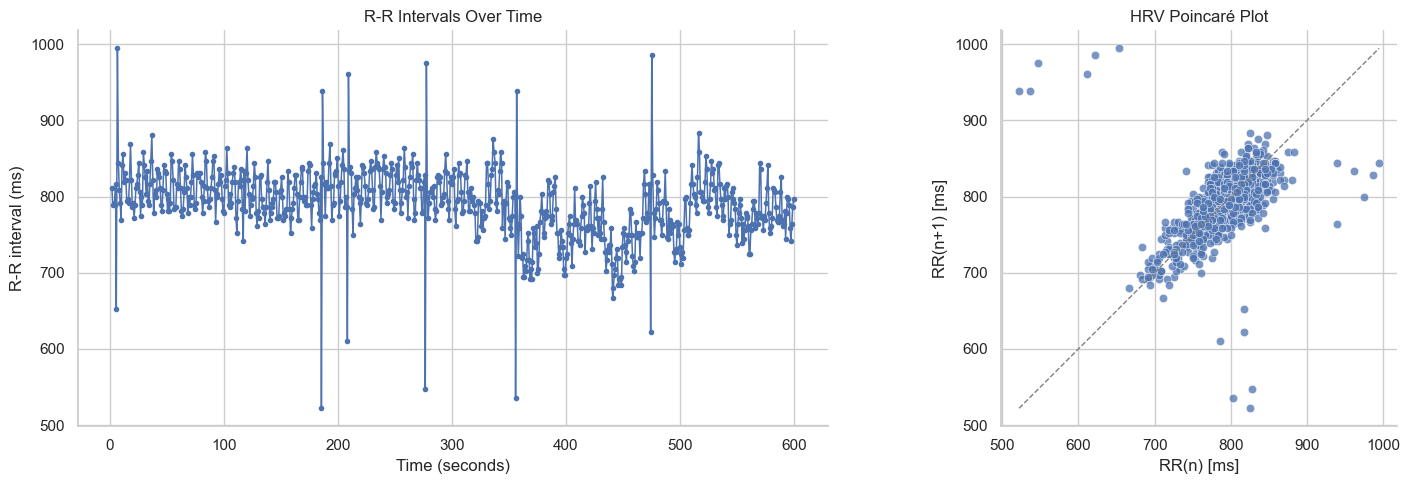

In [10]:
rr_intervals_ms = np.diff(rpeaks) / sampling_rate * 1000
rr_times_sec = rpeaks[1:] / sampling_rate

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(rr_times_sec, rr_intervals_ms, marker="o", linewidth=1.1, markersize=3)
axes[0].set_title("R-R Intervals Over Time")
axes[0].set_xlabel("Time (seconds)")
axes[0].set_ylabel("R-R interval (ms)")

if len(rr_intervals_ms) >= 2:
    axes[1].scatter(rr_intervals_ms[:-1], rr_intervals_ms[1:], alpha=0.75, edgecolor="white", linewidth=0.4)
    min_rr, max_rr = np.nanmin(rr_intervals_ms), np.nanmax(rr_intervals_ms)
    axes[1].plot([min_rr, max_rr], [min_rr, max_rr], color="gray", linestyle="--", linewidth=1)
axes[1].set_title("HRV Poincaré Plot")
axes[1].set_xlabel("RR(n) [ms]")
axes[1].set_ylabel("RR(n+1) [ms]")
axes[1].set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.show()

## 9. HRV Feature Summary

The table below prints a compact summary of selected HRV metrics. Some frequency-domain or nonlinear features may be `NaN` if the ECG segment is too short, too irregular, or unsuitable for the assumptions of that metric.

In [11]:
preferred_hrv_columns = [
    "HRV_MeanNN", "HRV_SDNN", "HRV_RMSSD", "HRV_pNN50",
    "HRV_LF", "HRV_HF", "HRV_LFHF",
    "HRV_SD1", "HRV_SD2", "HRV_SD1SD2", "HRV_SampEn",
]

available_columns = [col for col in preferred_hrv_columns if col in hrv_features.columns]
hrv_compact = hrv_features[available_columns].T.rename(columns={0: "value"})

display(hrv_compact)

print("Full HRV feature table shape:", hrv_features.shape)
print("All HRV feature columns:")
print(hrv_features.columns.tolist())

,value
HRV_MeanNN,789.651129
HRV_SDNN,44.888174
HRV_RMSSD,49.437550
HRV_pNN50,6.464380
HRV_LF,0.000820
HRV_HF,0.005587
HRV_LFHF,0.146729
HRV_SD1,34.980737
HRV_SD2,53.017818
HRV_SD1SD2,0.659792


Full HRV feature table shape: (1, 95)
All HRV feature columns:
['HRV_MeanNN', 'HRV_SDNN', 'HRV_SDANN1', 'HRV_SDNNI1', 'HRV_SDANN2', 'HRV_SDNNI2', 'HRV_SDANN5', 'HRV_SDNNI5', 'HRV_RMSSD', 'HRV_SDSD', 'HRV_CVNN', 'HRV_CVSD', 'HRV_MedianNN', 'HRV_MadNN', 'HRV_MCVNN', 'HRV_IQRNN', 'HRV_SDRMSSD', 'HRV_Prc20NN', 'HRV_Prc80NN', 'HRV_pNN50', 'HRV_pNN20', 'HRV_MinNN', 'HRV_MaxNN', 'HRV_HTI', 'HRV_TINN', 'HRV_ULF', 'HRV_VLF', 'HRV_LF', 'HRV_HF', 'HRV_VHF', 'HRV_TP', 'HRV_LFHF', 'HRV_LFn', 'HRV_HFn', 'HRV_LnHF', 'HRV_SD1', 'HRV_SD2', 'HRV_SD1SD2', 'HRV_S', 'HRV_CSI', 'HRV_CVI', 'HRV_CSI_Modified', 'HRV_PIP', 'HRV_IALS', 'HRV_PSS', 'HRV_PAS', 'HRV_GI', 'HRV_SI', 'HRV_AI', 'HRV_PI', 'HRV_C1d', 'HRV_C1a', 'HRV_SD1d', 'HRV_SD1a', 'HRV_C2d', 'HRV_C2a', 'HRV_SD2d', 'HRV_SD2a', 'HRV_Cd', 'HRV_Ca', 'HRV_SDNNd', 'HRV_SDNNa', 'HRV_DFA_alpha1', 'HRV_MFDFA_alpha1_Width', 'HRV_MFDFA_alpha1_Peak', 'HRV_MFDFA_alpha1_Mean', 'HRV_MFDFA_alpha1_Max', 'HRV_MFDFA_alpha1_Delta', 'HRV_MFDFA_alpha1_Asymmetry', 'HRV_MFDF

## 10. Compare NeuroKit2 R-Peaks with Expert MIT-BIH Annotations

MIT-BIH expert annotations mark beat locations and rhythm/event symbols. The overlay below lets you visually compare:

- Red triangles: NeuroKit2 detected R-peaks.
- Blue vertical lines: original expert annotation sample positions.

This is a visual diagnostic, not a full detection-performance study. A production evaluation should match detected peaks to expert beat annotations within a tolerance window, for example ±50 ms or ±100 ms, and then compute sensitivity, positive predictive value, and F1-score.

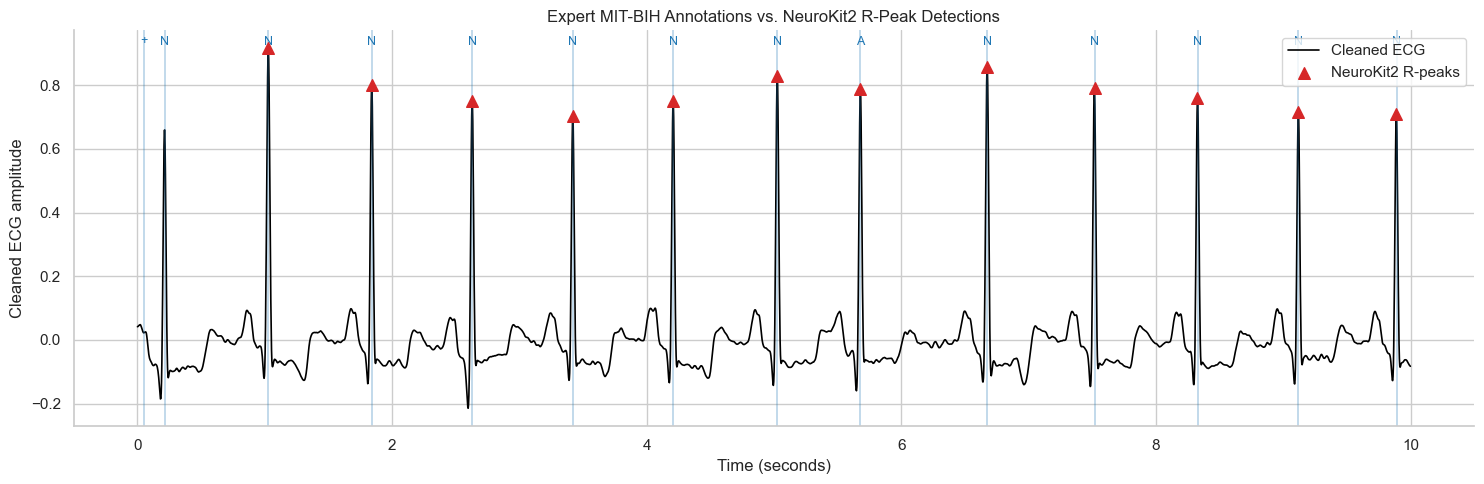

In [12]:
comparison_window = window_slice(start_seconds=0, duration_seconds=10, fs=sampling_rate, n_samples=len(cleaned_ecg))
start_sample, stop_sample = comparison_window.start, comparison_window.stop

rpeaks_in_window = rpeaks[(rpeaks >= start_sample) & (rpeaks < stop_sample)]
expert_in_window = expert_annotations[
    (expert_annotations["sample"] >= start_sample) &
    (expert_annotations["sample"] < stop_sample)
].copy()

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(time[comparison_window], cleaned_ecg.iloc[comparison_window], color="black", linewidth=1.2, label="Cleaned ECG")

ax.scatter(
    rpeaks_in_window / sampling_rate,
    cleaned_ecg.iloc[rpeaks_in_window],
    color="tab:red",
    marker="^",
    s=70,
    label="NeuroKit2 R-peaks",
    zorder=4,
)

for _, row in expert_in_window.iterrows():
    sample = int(row["sample"])
    ax.axvline(sample / sampling_rate, color="tab:blue", alpha=0.35, linewidth=1.1)
    ax.text(
        sample / sampling_rate,
        cleaned_ecg.iloc[comparison_window].max(),
        str(row["symbol"]),
        color="tab:blue",
        fontsize=9,
        ha="center",
        va="bottom",
    )

ax.set_title("Expert MIT-BIH Annotations vs. NeuroKit2 R-Peak Detections")
ax.set_xlabel("Time (seconds)")
ax.set_ylabel("Cleaned ECG amplitude")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## 11. Simple Quantitative Matching Against Expert Beat Locations

This optional cell matches each NeuroKit2 R-peak to the nearest expert annotation within a tolerance window. It treats MIT-BIH beat symbols as beat annotations and excludes non-beat rhythm markers where possible.

For rigorous reporting, review the exact MIT-BIH annotation symbols for your target task and decide which classes count as beats for your evaluation.

In [13]:
# Common MIT-BIH beat annotation symbols. Adjust this set for your specific evaluation protocol.
beat_symbols = {
    "N", "L", "R", "B", "A", "a", "J", "S", "V", "r", "F", "e", "j", "n", "E", "/", "f", "Q", "?"
}

expert_beats = expert_annotations[expert_annotations["symbol"].isin(beat_symbols)]["sample"].to_numpy(dtype=int)
tolerance_ms = 100
tolerance_samples = int((tolerance_ms / 1000) * sampling_rate)

matched_expert = set()
matched_detected = set()

for det_i, det_sample in enumerate(rpeaks):
    if len(expert_beats) == 0:
        break
    nearest_i = int(np.argmin(np.abs(expert_beats - det_sample)))
    nearest_sample = int(expert_beats[nearest_i])
    if abs(nearest_sample - det_sample) <= tolerance_samples and nearest_i not in matched_expert:
        matched_detected.add(det_i)
        matched_expert.add(nearest_i)

true_positives = len(matched_detected)
false_positives = len(rpeaks) - true_positives
false_negatives = len(expert_beats) - true_positives

sensitivity = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) else np.nan
positive_predictive_value = true_positives / (true_positives + false_positives) if (true_positives + false_positives) else np.nan
f1_score = 2 * sensitivity * positive_predictive_value / (sensitivity + positive_predictive_value) if (sensitivity + positive_predictive_value) else np.nan

evaluation_summary = pd.DataFrame({
    "tolerance_ms": [tolerance_ms],
    "expert_beats": [len(expert_beats)],
    "detected_rpeaks": [len(rpeaks)],
    "true_positives": [true_positives],
    "false_positives": [false_positives],
    "false_negatives": [false_negatives],
    "sensitivity": [sensitivity],
    "positive_predictive_value": [positive_predictive_value],
    "f1_score": [f1_score],
})

display(evaluation_summary)

,tolerance_ms,expert_beats,detected_rpeaks,true_positives,false_positives,false_negatives,sensitivity,positive_predictive_value,f1_score
0,100,760,759,759,0,1,0.998684,1.0,0.999342



## 11. Beat-by-Beat ECG Intervals and Wave Widths

NeuroKit2 delineation gives the fiducial sample locations needed to calculate clinical morphology intervals. This cell converts P/QRS/T landmarks into a beat-by-beat table with durations in milliseconds.

Computed measurements include:

- **P duration / width**: P onset to P offset.
- **PR interval**: P onset to QRS onset.
- **QRS duration / width**: QRS onset to QRS offset.
- **QT interval**: QRS onset to T offset.
- **ST segment**: QRS offset to T onset.
- **T duration / width**: T onset to T offset.
- **RR intervals**: previous and next R-to-R intervals.

These are automated estimates and should be quality-controlled before clinical use, especially for abnormal beats, noisy segments, or missing P/T waves.


In [14]:

def nearest_before(indices, anchor, max_distance=None):
    values = pd.Series(indices).dropna().astype(int).to_numpy() if indices is not None else np.array([], dtype=int)
    values = values[values < anchor]
    if len(values) == 0:
        return np.nan
    candidate = int(values[-1])
    if max_distance is not None and anchor - candidate > max_distance:
        return np.nan
    return candidate


def nearest_after(indices, anchor, max_distance=None):
    values = pd.Series(indices).dropna().astype(int).to_numpy() if indices is not None else np.array([], dtype=int)
    values = values[values > anchor]
    if len(values) == 0:
        return np.nan
    candidate = int(values[0])
    if max_distance is not None and candidate - anchor > max_distance:
        return np.nan
    return candidate


def samples_to_ms(sample_delta):
    return sample_delta / sampling_rate * 1000


# Conservative windows prevent landmarks from adjacent beats being paired together.
max_pr_samples = int(0.35 * sampling_rate)
max_qrs_side_samples = int(0.20 * sampling_rate)
max_t_samples = int(0.70 * sampling_rate)

rows = []
for beat_index, r_sample in enumerate(rpeaks):
    p_onset = nearest_before(delineate_info.get("ECG_P_Onsets"), r_sample, max_distance=max_pr_samples)
    p_peak = nearest_before(delineate_info.get("ECG_P_Peaks"), r_sample, max_distance=max_pr_samples)
    p_offset = nearest_before(delineate_info.get("ECG_P_Offsets"), r_sample, max_distance=max_pr_samples)
    q_peak = nearest_before(delineate_info.get("ECG_Q_Peaks"), r_sample, max_distance=max_qrs_side_samples)
    qrs_onset = nearest_before(delineate_info.get("ECG_R_Onsets"), r_sample, max_distance=max_qrs_side_samples)
    qrs_offset = nearest_after(delineate_info.get("ECG_R_Offsets"), r_sample, max_distance=max_qrs_side_samples)
    s_peak = nearest_after(delineate_info.get("ECG_S_Peaks"), r_sample, max_distance=max_qrs_side_samples)
    t_onset = nearest_after(delineate_info.get("ECG_T_Onsets"), r_sample, max_distance=max_t_samples)
    t_peak = nearest_after(delineate_info.get("ECG_T_Peaks"), r_sample, max_distance=max_t_samples)
    t_offset = nearest_after(delineate_info.get("ECG_T_Offsets"), r_sample, max_distance=max_t_samples)

    # Fall back to Q and S peaks when explicit QRS onset/offset are missing.
    qrs_start = qrs_onset if not pd.isna(qrs_onset) else q_peak
    qrs_end = qrs_offset if not pd.isna(qrs_offset) else s_peak

    rr_previous = samples_to_ms(r_sample - rpeaks[beat_index - 1]) if beat_index > 0 else np.nan
    rr_next = samples_to_ms(rpeaks[beat_index + 1] - r_sample) if beat_index < len(rpeaks) - 1 else np.nan

    row = {
        "beat_index": beat_index,
        "r_sample": int(r_sample),
        "r_time_sec": r_sample / sampling_rate,
        "p_onset_sample": p_onset,
        "p_peak_sample": p_peak,
        "p_offset_sample": p_offset,
        "q_peak_sample": q_peak,
        "qrs_onset_sample": qrs_start,
        "r_peak_sample": int(r_sample),
        "s_peak_sample": s_peak,
        "qrs_offset_sample": qrs_end,
        "t_onset_sample": t_onset,
        "t_peak_sample": t_peak,
        "t_offset_sample": t_offset,
        "rr_previous_ms": rr_previous,
        "rr_next_ms": rr_next,
        "p_duration_ms": samples_to_ms(p_offset - p_onset) if not pd.isna(p_onset) and not pd.isna(p_offset) else np.nan,
        "pr_interval_ms": samples_to_ms(qrs_start - p_onset) if not pd.isna(p_onset) and not pd.isna(qrs_start) else np.nan,
        "qrs_duration_ms": samples_to_ms(qrs_end - qrs_start) if not pd.isna(qrs_start) and not pd.isna(qrs_end) else np.nan,
        "qt_interval_ms": samples_to_ms(t_offset - qrs_start) if not pd.isna(qrs_start) and not pd.isna(t_offset) else np.nan,
        "st_segment_ms": samples_to_ms(t_onset - qrs_end) if not pd.isna(qrs_end) and not pd.isna(t_onset) else np.nan,
        "t_duration_ms": samples_to_ms(t_offset - t_onset) if not pd.isna(t_onset) and not pd.isna(t_offset) else np.nan,
        "r_amplitude": cleaned_ecg.iloc[int(r_sample)],
    }
    rows.append(row)

morphology_features = pd.DataFrame(rows)

summary_columns = [
    "rr_previous_ms", "p_duration_ms", "pr_interval_ms", "qrs_duration_ms",
    "qt_interval_ms", "st_segment_ms", "t_duration_ms",
]

print(f"Beat-by-beat morphology table shape: {morphology_features.shape}")
display(morphology_features.head(10))
display(morphology_features[summary_columns].describe().T)


Beat-by-beat morphology table shape: (759, 23)


,beat_index,r_sample,r_time_sec,p_onset_sample,p_peak_sample,p_offset_sample,q_peak_sample,qrs_onset_sample,r_peak_sample,s_peak_sample,...,t_offset_sample,rr_previous_ms,rr_next_ms,p_duration_ms,pr_interval_ms,qrs_duration_ms,qt_interval_ms,st_segment_ms,t_duration_ms,r_amplitude
0,0,370,1.027778,294,309,338,358,350,370,NaN,...,468.0,NaN,811.111111,122.222222,155.555556,102.777778,327.777778,86.111111,138.888889,0.915127
1,1,662,1.838889,586,603,610,651,644,662,NaN,...,721.0,811.111111,788.888889,66.666667,161.111111,88.888889,213.888889,75.000000,50.000000,0.801753
2,2,946,2.627778,863,884,890,935,925,946,957.0,...,1070.0,788.888889,791.666667,75.000000,172.222222,100.000000,402.777778,233.333333,69.444444,0.750677
3,3,1231,3.419444,1141,1168,1202,1220,1213,1231,NaN,...,1269.0,791.666667,788.888889,169.444444,200.000000,88.888889,155.555556,11.111111,55.555556,0.703215
4,4,1515,4.208333,1458,1462,1476,1504,1495,1515,NaN,...,1610.0,788.888889,816.666667,50.000000,102.777778,94.444444,319.444444,158.333333,66.666667,0.748739
5,5,1809,5.025000,1726,1746,1753,1798,1790,1809,1846.0,...,1873.0,816.666667,652.777778,75.000000,177.777778,94.444444,230.555556,72.222222,63.888889,0.827913
6,6,2044,5.677778,1961,1984,2003,2033,2025,2044,2080.0,...,2095.0,652.777778,994.444444,116.666667,177.777778,91.666667,194.444444,66.666667,36.111111,0.786239
7,7,2402,6.672222,2319,2338,2349,2390,2382,2402,2414.0,...,2504.0,994.444444,844.444444,83.333333,175.000000,102.777778,338.888889,136.111111,100.000000,0.856112
8,8,2706,7.516667,2624,2642,2649,2694,2686,2706,2716.0,...,2781.0,844.444444,808.333333,69.444444,172.222222,94.444444,263.888889,116.666667,52.777778,0.789293
9,9,2997,8.325000,2920,2937,2943,2987,2979,2997,3028.0,...,3072.0,808.333333,791.666667,63.888889,163.888889,88.888889,258.333333,113.888889,55.555556,0.760076


,count,mean,std,min,25%,50%,75%,max
rr_previous_ms,758.0,789.651129,44.888174,522.222222,766.666667,791.666667,819.444444,994.444444
p_duration_ms,759.0,84.595960,36.607244,41.666667,58.333333,72.222222,101.388889,213.888889
pr_interval_ms,759.0,157.839262,32.350309,97.222222,116.666667,172.222222,180.555556,233.333333
qrs_duration_ms,732.0,96.448087,5.675059,77.777778,91.666667,94.444444,100.000000,138.888889
qt_interval_ms,727.0,243.668806,80.284520,127.777778,180.555556,222.222222,297.222222,530.555556
st_segment_ms,726.0,82.537496,66.285501,-30.555556,30.555556,72.222222,125.000000,311.111111
t_duration_ms,727.0,64.836466,24.169846,27.777778,47.222222,58.333333,75.000000,208.333333



## 12. Visualize Widths and Interval Calculations for 20 Random Beats

This section randomly selects 20 beats with available morphology measurements and visualizes each beat in a local ECG window.

Each subplot shows:

- Cleaned ECG waveform around the selected R-peak.
- P, Q, R, S, and T landmarks when available.
- Numeric calculations for RR, P width, PR interval, QRS width, QT interval, ST segment, and T width.

The random seed makes the selected beats reproducible. Change `RANDOM_BEAT_SEED` to inspect a different set.


In [15]:

RANDOM_BEAT_SEED = 42
N_RANDOM_BEATS = 20

interval_columns = [
    "rr_previous_ms",
    "rr_next_ms",
    "p_duration_ms",
    "pr_interval_ms",
    "qrs_duration_ms",
    "qt_interval_ms",
    "st_segment_ms",
    "t_duration_ms",
]

# Prefer beats with QRS duration and at least one major interval available.
eligible_beats = morphology_features.dropna(
    subset=["qrs_duration_ms", "pr_interval_ms"],
    how="any",
).copy()

if len(eligible_beats) < N_RANDOM_BEATS:
    eligible_beats = morphology_features.dropna(subset=["qrs_duration_ms"]).copy()

random_beats = (
    eligible_beats
    .sample(n=min(N_RANDOM_BEATS, len(eligible_beats)), random_state=RANDOM_BEAT_SEED)
    .sort_values("r_sample")
    .reset_index(drop=True)
)

display_columns = ["beat_index", "r_time_sec"] + interval_columns
display(random_beats[display_columns].round(2))

print(f"Selected {len(random_beats)} random beats using seed {RANDOM_BEAT_SEED}.")


,beat_index,r_time_sec,rr_previous_ms,rr_next_ms,p_duration_ms,pr_interval_ms,qrs_duration_ms,qt_interval_ms,st_segment_ms,t_duration_ms
0,33,27.77,800.00,788.89,116.67,166.67,100.00,158.33,-11.11,69.44
1,39,32.72,833.33,794.44,69.44,169.44,91.67,294.44,155.56,47.22
2,68,56.31,783.33,786.11,111.11,172.22,91.67,161.11,11.11,58.33
3,74,61.19,836.11,811.11,52.78,111.11,97.22,155.56,22.22,36.11
4,80,65.99,841.67,825.00,50.00,113.89,94.44,316.67,150.00,72.22
5,169,137.83,819.44,847.22,91.67,197.22,94.44,205.56,61.11,50.00
6,187,152.18,769.44,777.78,147.22,169.44,97.22,188.89,33.33,58.33
7,308,249.97,791.67,827.78,61.11,152.78,97.22,222.22,58.33,66.67
8,368,298.48,819.44,825.00,83.33,183.33,105.56,180.56,25.00,50.00
9,369,299.31,825.00,816.67,141.67,177.78,105.56,161.11,16.67,38.89


Selected 20 random beats using seed 42.


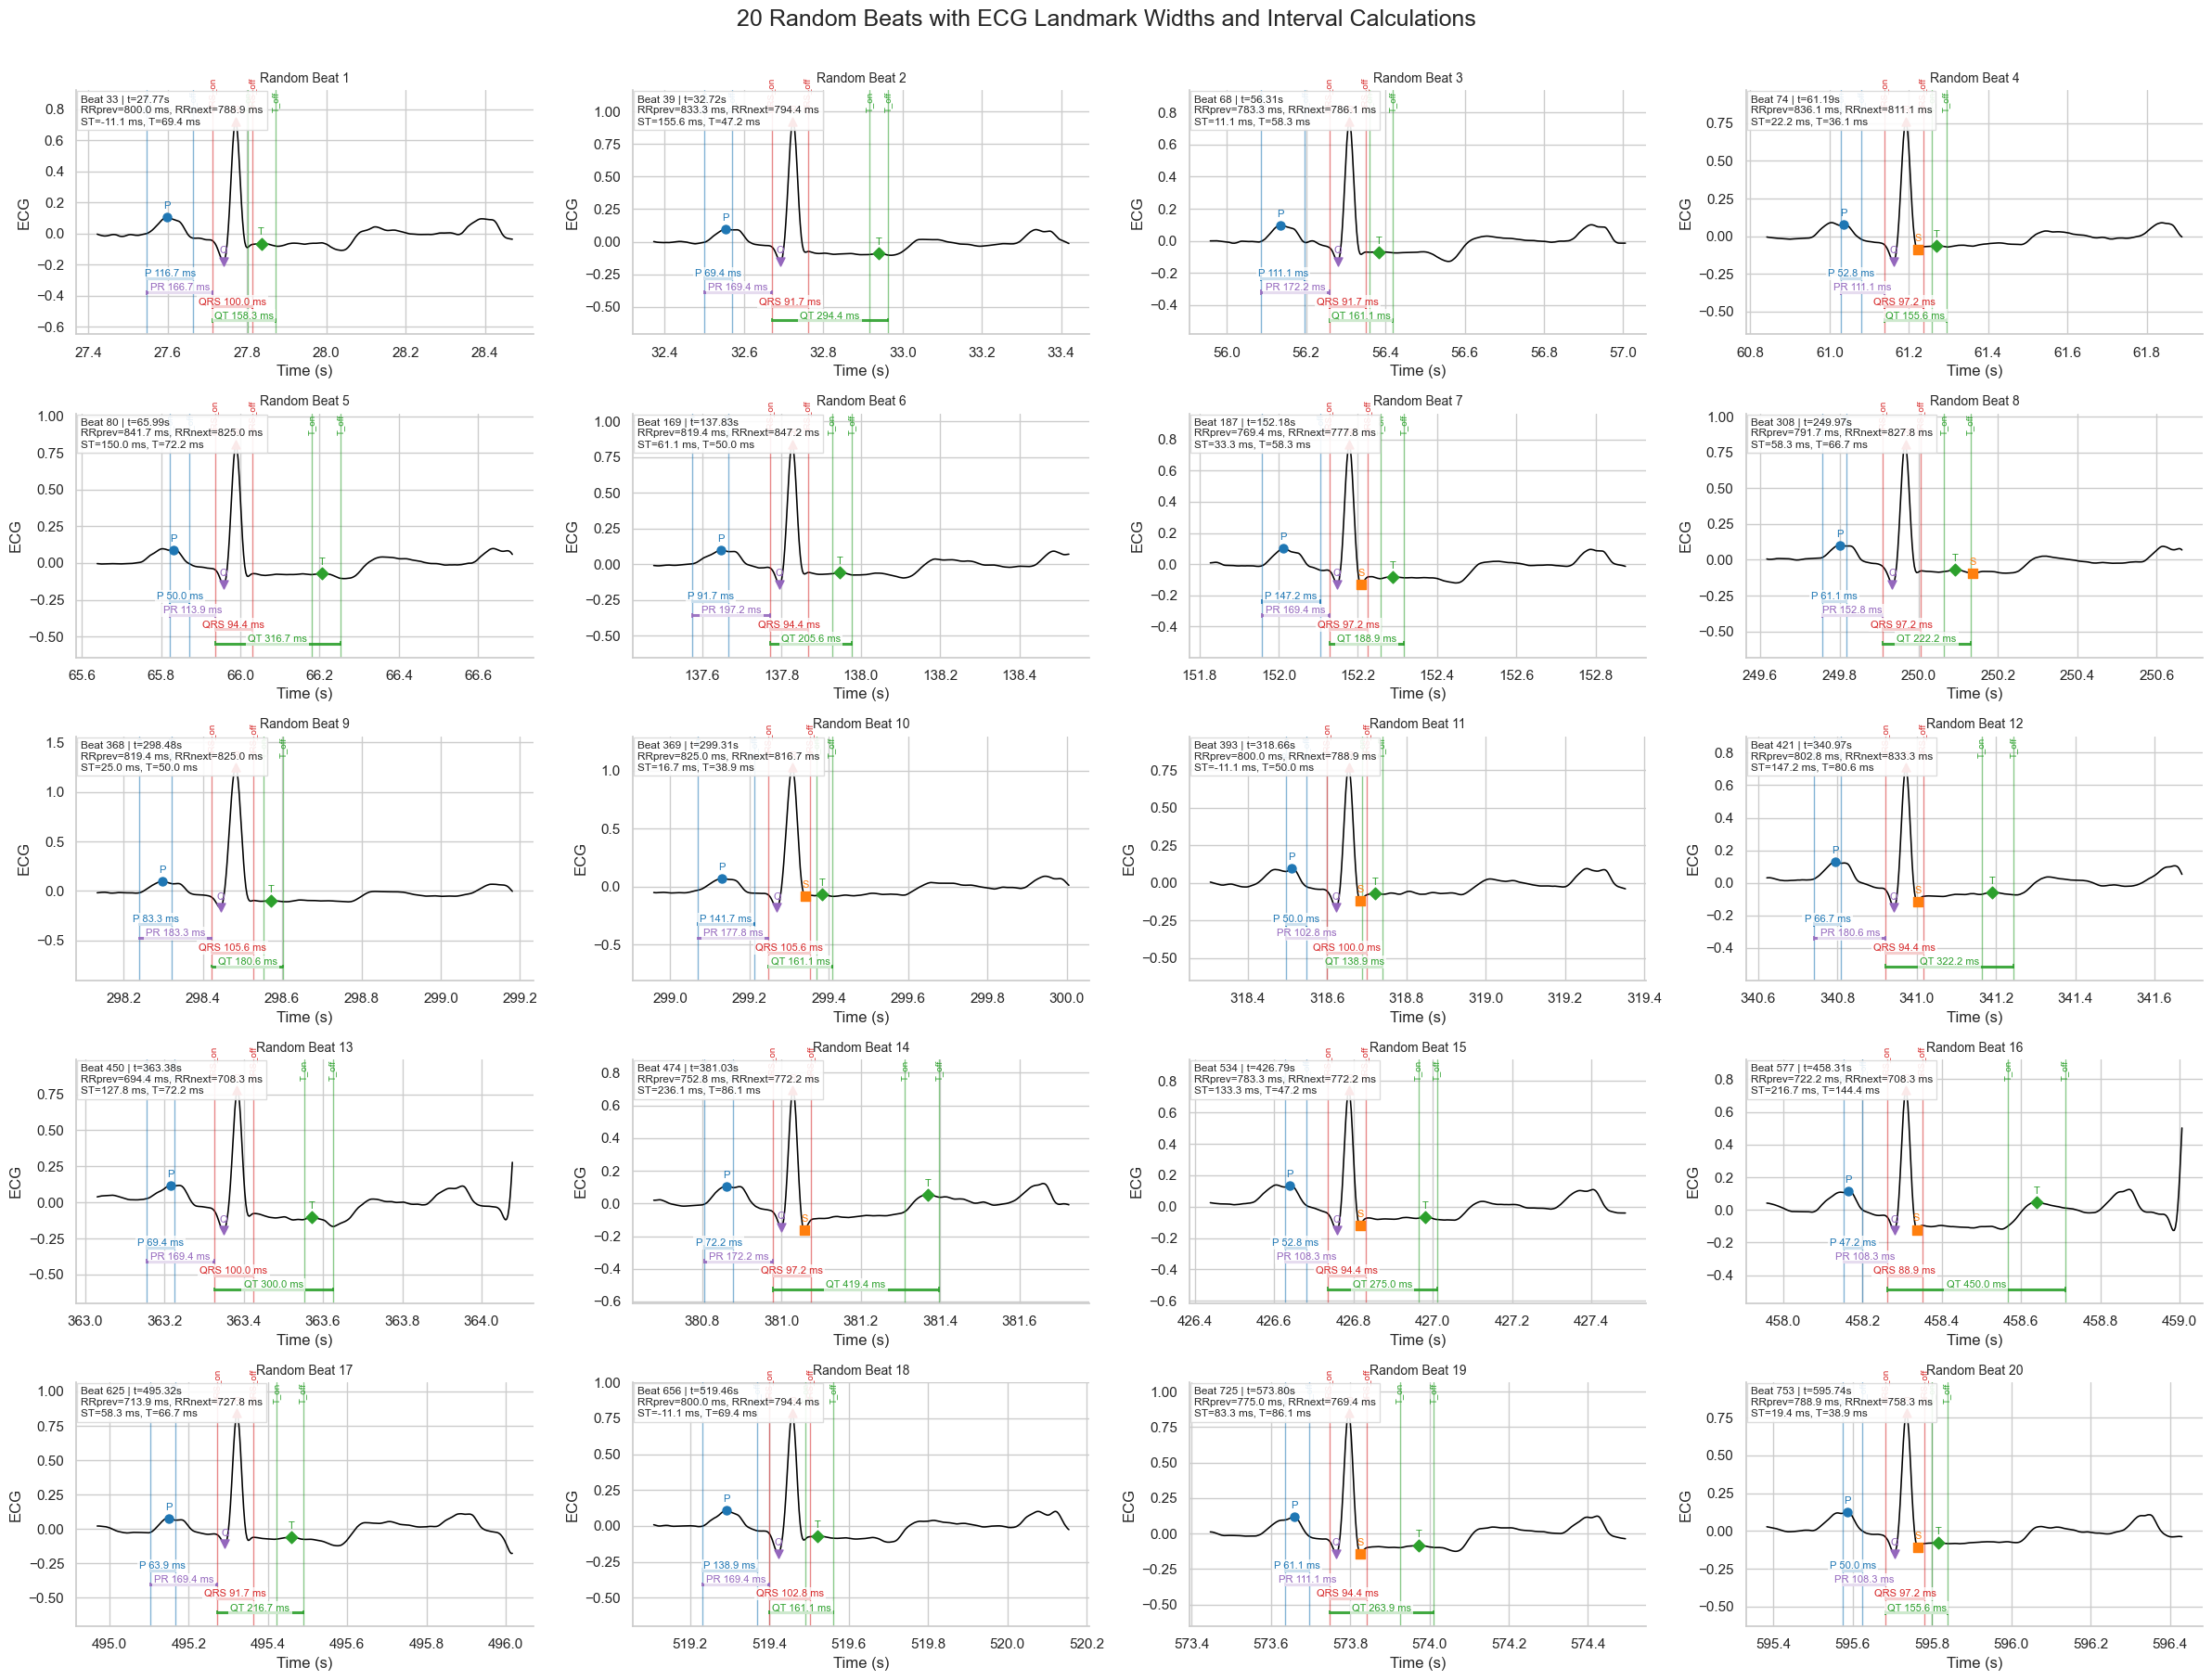

In [16]:

def format_ms(value):
    if pd.isna(value):
        return "NA"
    return f"{value:.1f}"


landmark_specs = {
    "P_on": ("p_onset_sample", "tab:blue", "|"),
    "P": ("p_peak_sample", "tab:blue", "o"),
    "P_off": ("p_offset_sample", "tab:blue", "|"),
    "Q": ("q_peak_sample", "tab:purple", "v"),
    "QRS_on": ("qrs_onset_sample", "tab:red", "|"),
    "R": ("r_peak_sample", "tab:red", "^"),
    "S": ("s_peak_sample", "tab:orange", "s"),
    "QRS_off": ("qrs_offset_sample", "tab:red", "|"),
    "T_on": ("t_onset_sample", "tab:green", "|"),
    "T": ("t_peak_sample", "tab:green", "D"),
    "T_off": ("t_offset_sample", "tab:green", "|"),
}


def add_interval_span(ax, row, start_col, end_col, y, label, color):
    start = row.get(start_col)
    end = row.get(end_col)
    if pd.isna(start) or pd.isna(end) or end <= start:
        return
    ax.hlines(y, start / sampling_rate, end / sampling_rate, color=color, linewidth=2.2, alpha=0.9)
    ax.vlines([start / sampling_rate, end / sampling_rate], y - 0.015, y + 0.015, color=color, linewidth=1.2)
    ax.text(
        (start + end) / (2 * sampling_rate),
        y,
        label,
        color=color,
        fontsize=8,
        ha="center",
        va="bottom",
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.75, "pad": 1.5},
    )


n_rows = 5
n_cols = 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 18), sharex=False, sharey=False)
axes = axes.ravel()

for ax_index, (_, row) in enumerate(random_beats.iterrows()):
    ax = axes[ax_index]
    r_sample = int(row["r_sample"])
    beat_slice = window_slice(
        start_seconds=max(0, (r_sample / sampling_rate) - 0.35),
        duration_seconds=1.05,
        fs=sampling_rate,
        n_samples=len(cleaned_ecg),
    )

    beat_time = time[beat_slice]
    beat_signal = cleaned_ecg.iloc[beat_slice]
    ax.plot(beat_time, beat_signal, color="black", linewidth=1.15)

    y_min = float(np.nanmin(beat_signal))
    y_max = float(np.nanmax(beat_signal))
    y_span = max(y_max - y_min, 1e-6)

    for label, (sample_col, color, marker) in landmark_specs.items():
        sample = row.get(sample_col)
        if pd.isna(sample):
            continue
        sample = int(sample)
        if sample < beat_slice.start or sample >= beat_slice.stop:
            continue
        x = sample / sampling_rate
        y = cleaned_ecg.iloc[sample]
        if marker == "|":
            ax.axvline(x, color=color, alpha=0.55, linewidth=1)
            ax.text(x, y_max + 0.08 * y_span, label, color=color, fontsize=7, ha="center", rotation=90)
        else:
            ax.scatter(x, y, color=color, marker=marker, s=42, zorder=3)
            ax.text(x, y + 0.06 * y_span, label, color=color, fontsize=8, ha="center")

    add_interval_span(
        ax,
        row,
        "p_onset_sample",
        "p_offset_sample",
        y_min - 0.12 * y_span,
        f"P {format_ms(row['p_duration_ms'])} ms",
        "tab:blue",
    )
    add_interval_span(
        ax,
        row,
        "p_onset_sample",
        "qrs_onset_sample",
        y_min - 0.22 * y_span,
        f"PR {format_ms(row['pr_interval_ms'])} ms",
        "tab:purple",
    )
    add_interval_span(
        ax,
        row,
        "qrs_onset_sample",
        "qrs_offset_sample",
        y_min - 0.32 * y_span,
        f"QRS {format_ms(row['qrs_duration_ms'])} ms",
        "tab:red",
    )
    add_interval_span(
        ax,
        row,
        "qrs_onset_sample",
        "t_offset_sample",
        y_min - 0.42 * y_span,
        f"QT {format_ms(row['qt_interval_ms'])} ms",
        "tab:green",
    )

    metrics_text = (
        f"Beat {int(row['beat_index'])} | t={row['r_time_sec']:.2f}s\n"
        f"RRprev={format_ms(row['rr_previous_ms'])} ms, RRnext={format_ms(row['rr_next_ms'])} ms\n"
        f"ST={format_ms(row['st_segment_ms'])} ms, T={format_ms(row['t_duration_ms'])} ms"
    )
    ax.text(
        0.01,
        0.98,
        metrics_text,
        transform=ax.transAxes,
        fontsize=8.5,
        va="top",
        ha="left",
        bbox={"facecolor": "white", "edgecolor": "0.85", "alpha": 0.9, "pad": 3},
    )

    ax.set_title(f"Random Beat {ax_index + 1}", fontsize=10)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("ECG")
    ax.set_ylim(y_min - 0.52 * y_span, y_max + 0.22 * y_span)

for empty_ax in axes[len(random_beats):]:
    empty_ax.axis("off")

fig.suptitle("20 Random Beats with ECG Landmark Widths and Interval Calculations", fontsize=18, y=1.005)
plt.tight_layout()
plt.show()


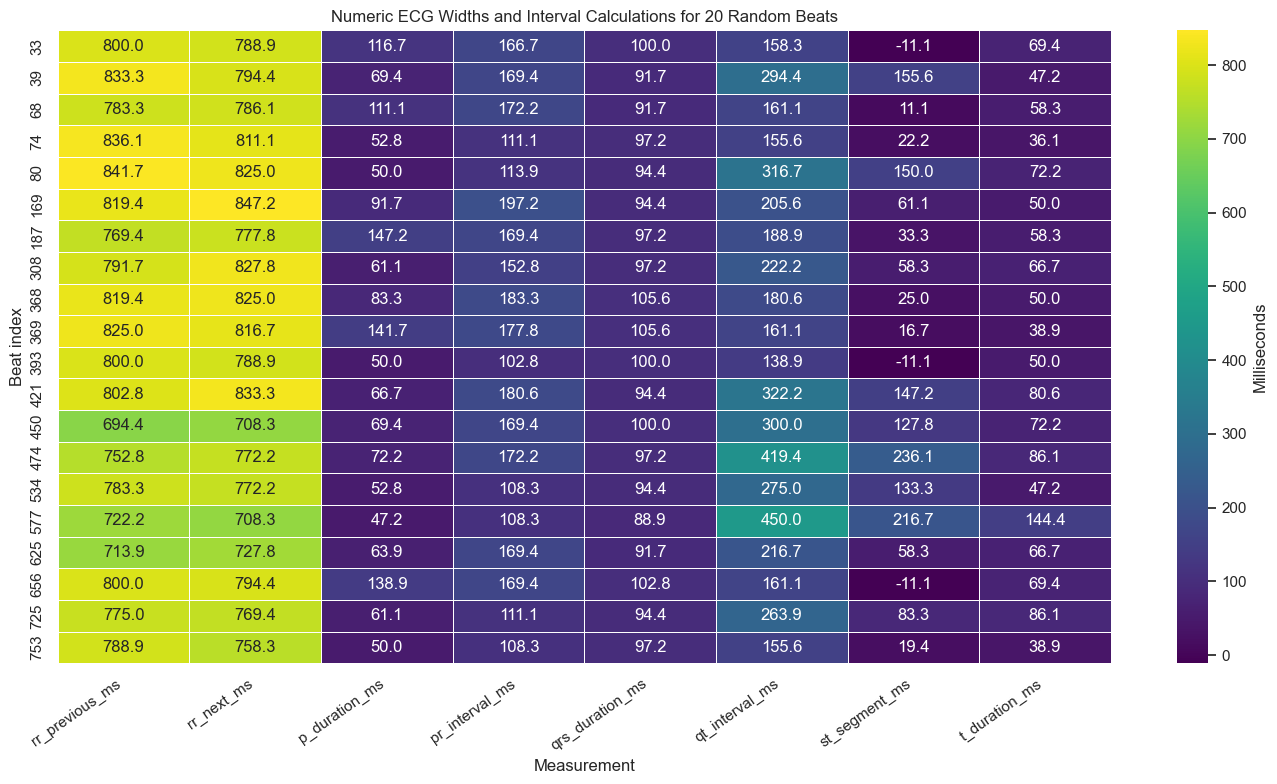

Saved 20 random beat calculations to: D:\DEPI Project\Graduation project\outputs\neurokit2_mitbih\record_100_MLII_20_random_beats_widths.csv


In [17]:

random_beat_metrics = random_beats.set_index("beat_index")[interval_columns].copy()

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(
    random_beat_metrics,
    annot=True,
    fmt=".1f",
    cmap="viridis",
    linewidths=0.5,
    cbar_kws={"label": "Milliseconds"},
    ax=ax,
)
ax.set_title("Numeric ECG Widths and Interval Calculations for 20 Random Beats")
ax.set_xlabel("Measurement")
ax.set_ylabel("Beat index")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

output_dir = Path("outputs") / "neurokit2_mitbih"
output_dir.mkdir(parents=True, exist_ok=True)
random_beats.to_csv(output_dir / f"record_{RECORD_NAME}_{lead_name}_20_random_beats_widths.csv", index=False)
print(f"Saved 20 random beat calculations to: {(output_dir / f'record_{RECORD_NAME}_{lead_name}_20_random_beats_widths.csv').resolve()}")


## 12. Save Processed Outputs

The final cell exports the processed ECG sample-by-sample summary and HRV feature table. These files can feed your downstream modeling, reporting, or dashboard pipeline.

In [18]:
output_dir = Path("outputs") / "neurokit2_mitbih"
output_dir.mkdir(parents=True, exist_ok=True)

ecg_summary.to_csv(output_dir / f"record_{RECORD_NAME}_{lead_name}_ecg_summary.csv", index=False)
hrv_features.to_csv(output_dir / f"record_{RECORD_NAME}_{lead_name}_hrv_features.csv", index=False)
expert_annotations.to_csv(output_dir / f"record_{RECORD_NAME}_expert_annotations.csv", index=False)
morphology_features.to_csv(output_dir / f"record_{RECORD_NAME}_{lead_name}_morphology_intervals_widths.csv", index=False)

print(f"Saved outputs to: {output_dir.resolve()}")

Saved outputs to: D:\DEPI Project\Graduation project\outputs\neurokit2_mitbih
